Image Fourier Transform

In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image

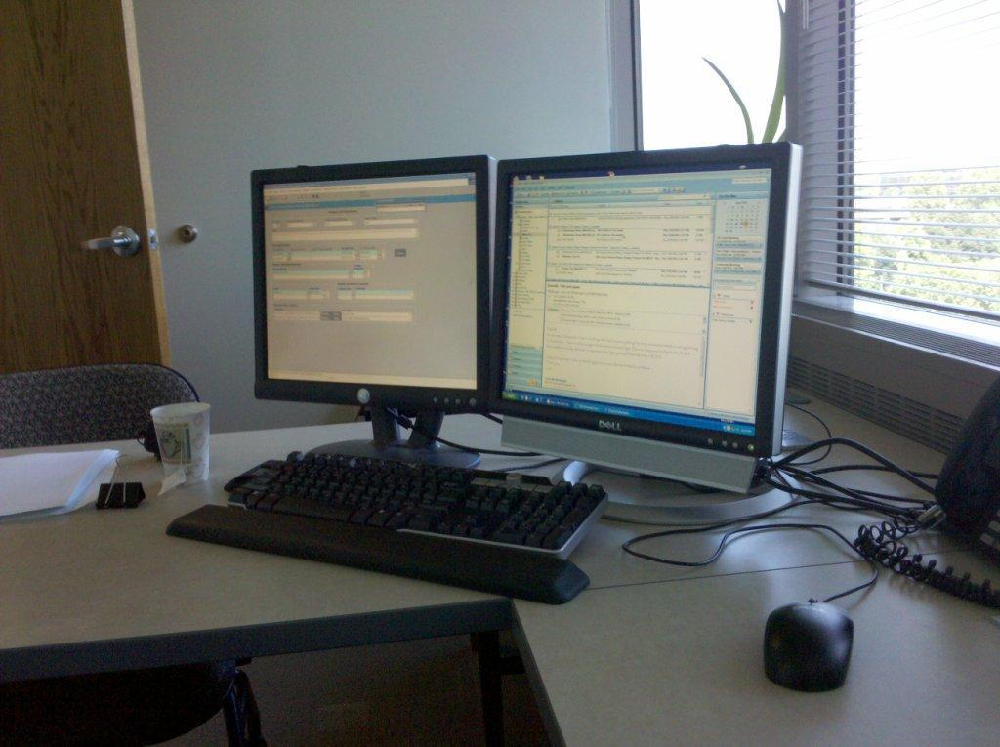

In [2]:
image_path = "/gpfs-flash/junlab/liyuan/hongwei/config/data/OfficeHomeDataset_10072016/Real World/Computer/00008.jpg"
# image_path = "/gpfs-flash/junlab/liyuan/hongwei/config/data/OfficeHomeDataset_10072016/Clipart/Helmet/00008.jpg"
image = Image.open(image_path)
image.show()

In [3]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)
print(image_tensor.shape)

torch.Size([1, 3, 256, 256])


In [4]:
fft_result = torch.fft.fft2(image_tensor)
fft_shifted = torch.fft.fftshift(fft_result)
print(fft_shifted.shape)
print(fft_shifted.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


visualization the fft result

In [5]:
magnitude = torch.abs(fft_shifted)
phase = torch.angle(fft_shifted)

print(magnitude.max(), magnitude.min())
print(phase.max(), phase.min())

tensor(26953.3418) tensor(0.0046)
tensor(3.1416) tensor(-3.1416)


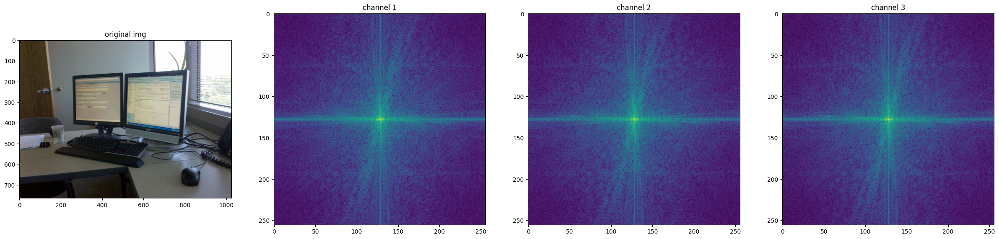

In [6]:
magnitude_vis = torch.log(1+magnitude)

plt.figure(figsize=(30,10))

plt.subplot(1,4,1)
plt.title('original img')
plt.imshow(image)

plt.subplot(1,4,2)
plt.title('channel 1')
plt.imshow(magnitude_vis[:,0].squeeze())

plt.subplot(1,4,3)
plt.title('channel 2')
plt.imshow(magnitude_vis[:,1].squeeze())

plt.subplot(1,4,4)
plt.title('channel 3')
plt.imshow(magnitude_vis[:,2].squeeze())

plt.show()

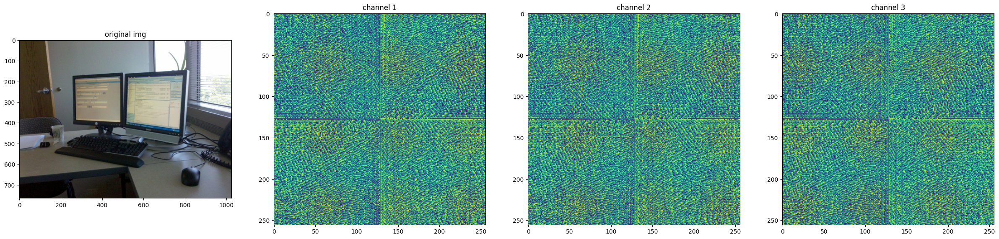

In [7]:
plt.figure(figsize=(30,10))

plt.subplot(1,4,1)
plt.title('original img')
plt.imshow(image)

plt.subplot(1,4,2)
plt.title('channel 1')
plt.imshow(phase[:,0].squeeze())

plt.subplot(1,4,3)
plt.title('channel 2')
plt.imshow(phase[:,1].squeeze())

plt.subplot(1,4,4)
plt.title('channel 3')
plt.imshow(phase[:,2].squeeze())

plt.show()

inverse visualization

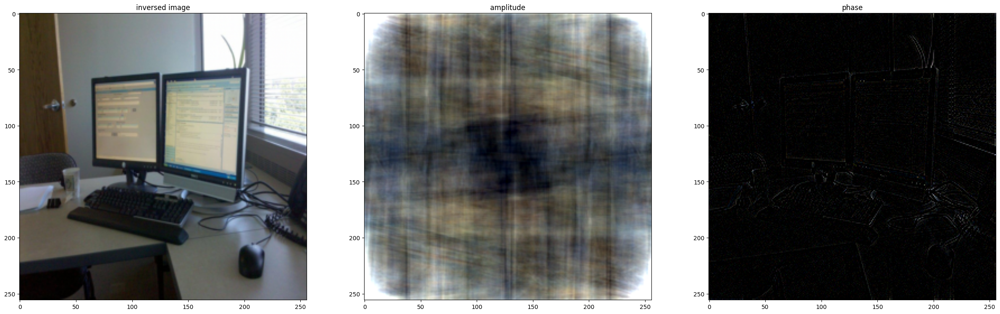

In [8]:
i_magnitude = torch.fft.ifftshift(magnitude)
i_phase = torch.fft.ifftshift(phase)

i_complex = i_magnitude * torch.exp(1j * i_phase)
i_image_1_1 = torch.fft.ifft2(i_complex).real

# eliminate the phase information
null_phase = torch.zeros_like(i_phase)
i_complex = i_magnitude * torch.exp(1j * null_phase)
i_image_1_0 = torch.fft.ifft2(i_complex).real

# eliminate the amplitude information
null_amplitude = torch.zeros_like(i_magnitude) + torch.mean(i_magnitude)
i_complex = null_amplitude * torch.exp(1j * i_phase)
i_image_0_1 = torch.fft.ifft2(i_complex).real

plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
plt.title('inversed image')
plt.imshow(i_image_1_1[0].permute(1, 2, 0).clamp(0, 1))

plt.subplot(1, 3, 2)
plt.title('amplitude')
plt.imshow(i_image_1_0[0].permute(1, 2, 0).clamp(0, 1))


plt.subplot(1, 3, 3)
plt.title('phase')
plt.imshow(i_image_0_1[0].permute(1, 2, 0).clamp(0, 1))

plt.show()

Another Image

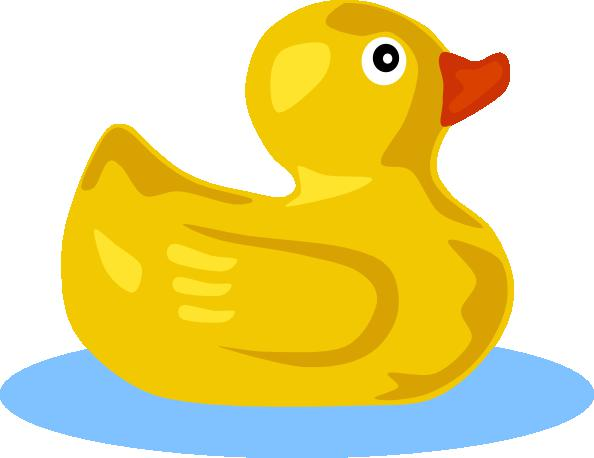

In [9]:
image_path_2 = "/gpfs-flash/junlab/liyuan/hongwei/config/data/OfficeHomeDataset_10072016/Clipart/Toys/00016.jpg"
image_2 = Image.open(image_path_2)
image_2.show()

In [10]:
image_tensor_2 = transform(image_2).unsqueeze(0)
print(image_tensor_2.shape)

torch.Size([1, 3, 256, 256])


In [11]:
fft_result_2 = torch.fft.fft2(image_tensor_2)
fft_shifted_2 = torch.fft.fftshift(fft_result_2)
print(fft_shifted_2.shape)
print(fft_shifted_2.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


In [12]:
magnitude_2 = torch.abs(fft_shifted_2)
phase_2 = torch.angle(fft_shifted_2)

print(magnitude_2.max(), magnitude_2.min())
print(phase_2.max(), phase_2.min())

tensor(58926.2109) tensor(0.0066)
tensor(3.1416) tensor(-3.1416)


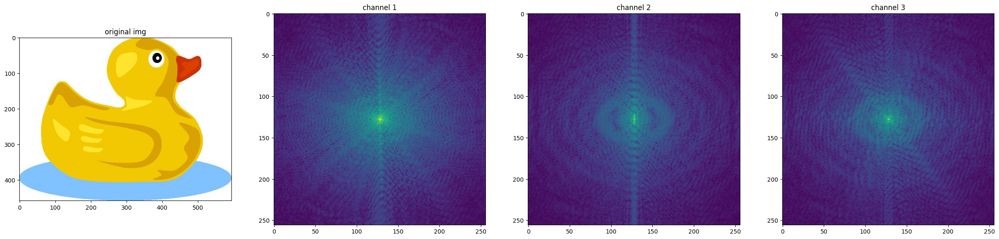

In [13]:
magnitude_vis_2 = torch.log(1+magnitude_2)

plt.figure(figsize=(30,10))

plt.subplot(1,4,1)
plt.title('original img')
plt.imshow(image_2)

plt.subplot(1,4,2)
plt.title('channel 1')
plt.imshow(magnitude_vis_2[:,0].squeeze())

plt.subplot(1,4,3)
plt.title('channel 2')
plt.imshow(magnitude_vis_2[:,1].squeeze())

plt.subplot(1,4,4)
plt.title('channel 3')
plt.imshow(magnitude_vis_2[:,2].squeeze())

plt.show()

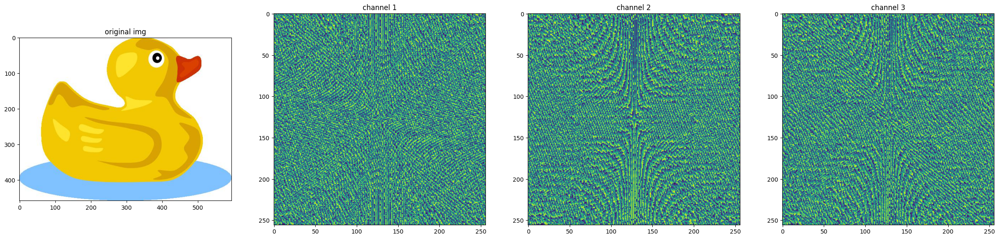

In [14]:
plt.figure(figsize=(30,10))

plt.subplot(1,4,1)
plt.title('original img')
plt.imshow(image_2)

plt.subplot(1,4,2)
plt.title('channel 1')
plt.imshow(phase_2[:,0].squeeze())

plt.subplot(1,4,3)
plt.title('channel 2')
plt.imshow(phase_2[:,1].squeeze())

plt.subplot(1,4,4)
plt.title('channel 3')
plt.imshow(phase_2[:,2].squeeze())

plt.show()

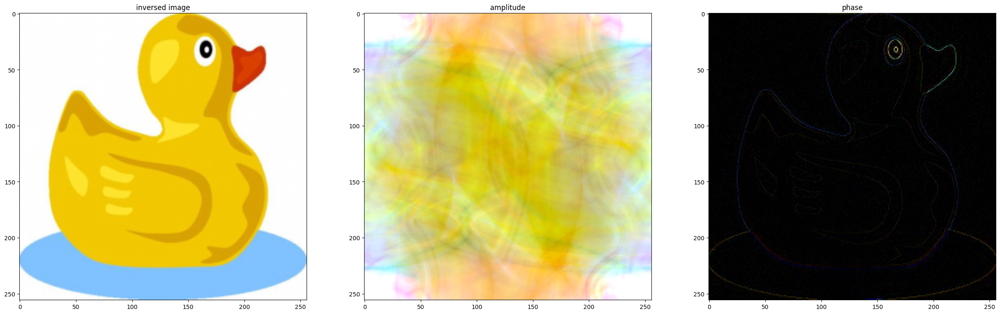

In [15]:
i_magnitude_2 = torch.fft.ifftshift(magnitude_2)
i_phase_2 = torch.fft.ifftshift(phase_2)

i_complex_2 = i_magnitude_2 * torch.exp(1j * i_phase_2)
i_image_2_2 = torch.fft.ifft2(i_complex_2).real

# eliminate the phase information
null_phase_2 = torch.zeros_like(i_phase_2)
i_complex_2 = i_magnitude_2 * torch.exp(1j * null_phase_2)
i_image_2_0 = torch.fft.ifft2(i_complex_2).real

# eliminate the amplitude information
null_amplitude_2 = torch.zeros_like(i_magnitude_2) + torch.mean(i_magnitude_2)
i_complex_2 = null_amplitude_2 * torch.exp(1j * i_phase_2)
i_image_0_2 = torch.fft.ifft2(i_complex_2).real

plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
plt.title('inversed image')
plt.imshow(i_image_2_2[0].permute(1, 2, 0).clamp(0, 1))

plt.subplot(1, 3, 2)
plt.title('amplitude')
plt.imshow(i_image_2_0[0].permute(1, 2, 0).clamp(0, 1))


plt.subplot(1, 3, 3)
plt.title('phase')
plt.imshow(i_image_0_2[0].permute(1, 2, 0).clamp(0, 1))

plt.show()

now we do composition

tensor(1.4600) tensor(-1.4899)


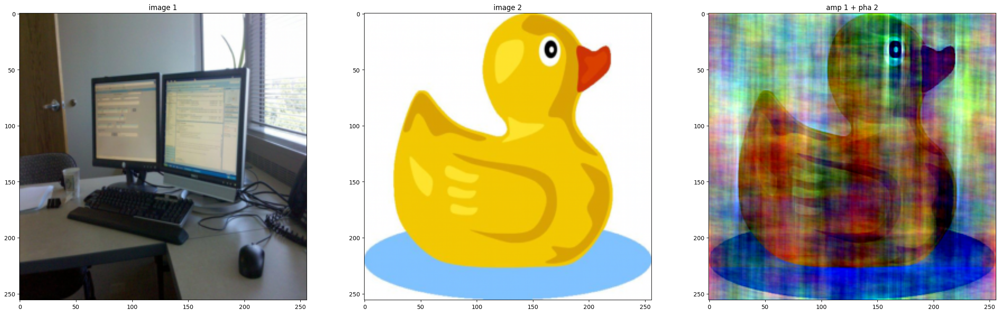

In [16]:
# composition one m_1 + p_2
i_complex_3 = i_magnitude * torch.exp(1j * i_phase_2)
i_image_1_2 = torch.fft.ifft2(i_complex_3).real

print(i_image_1_2.max(), i_image_1_2.min())

plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
plt.title('image 1')
plt.imshow(i_image_1_1[0].permute(1, 2, 0).clamp(0, 1))

plt.subplot(1, 3, 2)
plt.title('image 2')
plt.imshow(i_image_2_2[0].permute(1, 2, 0).clamp(0, 1))


plt.subplot(1, 3, 3)
plt.title('amp 1 + pha 2')
plt.imshow(i_image_1_2[0].permute(1, 2, 0).clamp(0, 1))

plt.show()

tensor(2.2273) tensor(-1.4899)


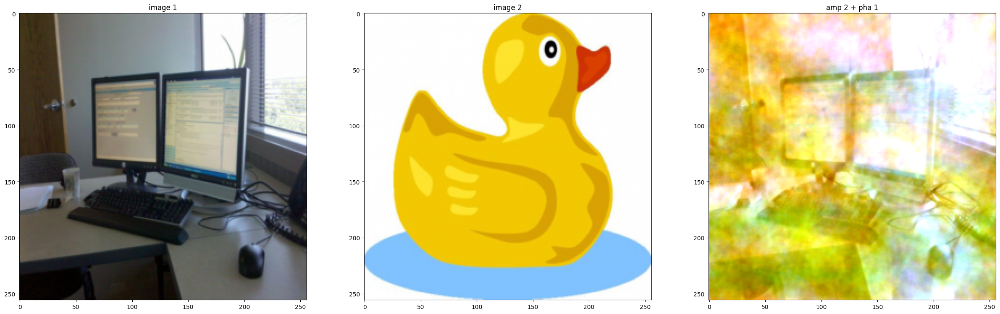

In [17]:
# composition one amp 2 + pha 1
i_complex_4 = i_magnitude_2 * torch.exp(1j * i_phase)
i_image_2_1 = torch.fft.ifft2(i_complex_4).real

print(i_image_2_1.max(), i_image_1_2.min())

plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
plt.title('image 1')
plt.imshow(i_image_1_1[0].permute(1, 2, 0).clamp(0, 1))

plt.subplot(1, 3, 2)
plt.title('image 2')
plt.imshow(i_image_2_2[0].permute(1, 2, 0).clamp(0, 1))


plt.subplot(1, 3, 3)
plt.title('amp 2 + pha 1')
plt.imshow(i_image_2_1[0].permute(1, 2, 0).clamp(0, 1))

plt.show()